<a href="https://colab.research.google.com/github/bhawana2401/Bank-Loan-Portfolio-Performance-Risk-Analytics/blob/main/Bank_Loan_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('Loan_Details.csv',low_memory=False)

In [3]:
df.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='object', length=151)

In [4]:
df.describe()

,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,fico_range_low,...,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term
count,0.0,745993.000000,745993.000000,745993.000000,745993.000000,745993.000000,7.459930e+05,745532.000000,745993.000000,745993.000000,...,4541.0,4541.000000,4541.0,4541.000000,3641.000000,4541.000000,4541.000000,15316.000000,15316.000000,15316.000000
mean,NaN,15200.544140,15200.506607,15195.086341,12.699047,444.964251,7.765365e+04,19.274470,0.332412,697.085824,...,3.0,141.547732,3.0,14.101740,418.300168,10851.579947,189.206628,4990.304615,47.661789,13.439149
std,NaN,9055.552665,9055.554680,9052.942606,4.690058,261.595700,1.477612e+05,14.076781,0.913718,32.529849,...,0.0,123.779901,0.0,9.586116,363.950214,7370.872352,192.318246,3655.612922,6.490899,7.700212
min,NaN,1000.000000,1000.000000,900.000000,5.310000,14.010000,0.000000e+00,0.000000,0.000000,660.000000,...,3.0,0.640000,3.0,0.000000,1.920000,55.730000,0.010000,107.000000,0.450000,0.000000
25%,NaN,8000.000000,8000.000000,8000.000000,9.170000,255.140000,4.600000e+04,12.260000,0.000000,670.000000,...,3.0,50.900000,3.0,6.000000,151.710000,5027.060000,43.850000,2187.000000,45.000000,8.000000
50%,NaN,13350.000000,13350.000000,13325.000000,12.290000,380.190000,6.500000e+04,18.340000,0.000000,690.000000,...,3.0,107.900000,3.0,15.000000,322.260000,9299.020000,129.940000,4201.000000,45.000000,14.000000
75%,NaN,20000.000000,20000.000000,20000.000000,15.410000,589.570000,9.240000e+04,25.190000,0.000000,715.000000,...,3.0,195.460000,3.0,23.000000,574.530000,15111.690000,278.490000,6865.000000,50.000000,18.000000
max,NaN,40000.000000,40000.000000,40000.000000,30.990000,1719.830000,1.100000e+08,999.000000,39.000000,845.000000,...,3.0,943.940000,3.0,31.000000,2680.890000,40306.410000,1290.590000,30000.000000,166.670000,112.000000


In [5]:
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')

Total Loan Applications

In [6]:
total_loan_applications = df['id'].count()
print("Total Loan Applications : ",total_loan_applications)

Total Loan Applications :  745999


MTD Total Loan Applications

In [7]:
latest_issue_date = df['issue_d'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month


mtd_data = df[(df['issue_d'].dt.year == latest_year) & (df['issue_d'].dt.month == latest_month)]

mtd_loan_applications = mtd_data['id'].count()

print(f"MTD Total Loan Applications (for {latest_issue_date.strftime('%b %Y')}) : {mtd_loan_applications}")

MTD Total Loan Applications (for Mar 2018) : 38771


Total Funded Amount

In [8]:
total_funded_amount = df['loan_amnt'].sum()

total_funded_amount_million = total_funded_amount/1000000

print("Total Funded Amount : ${:.2f}M".format(total_funded_amount_million))

Total Funded Amount : $11339.50M


MTD Total Funded Amount

In [9]:
mtd_total_loan_funded_amount = mtd_data['loan_amnt'].sum()

mtd_total_loan_funded_amount_million = mtd_total_loan_funded_amount/1000000

print("MTD Total Loan Funded Amount (for {}) : ${:.2f}M".format(
    latest_issue_date.strftime('%b %Y'),
    mtd_total_loan_funded_amount_million
))

MTD Total Loan Funded Amount (for Mar 2018) : $624.41M


Total Amount Received

In [10]:
total_amount_recevied = df['total_pymnt'].sum()

total_amount_recevied_million = total_amount_recevied/1000000

print("Total Amount Recevied : ${:.2f}M".format(total_amount_recevied_million))

Total Amount Recevied : $10039.35M


MTD Total Amount Received

In [11]:
mtd_total_amount_recevied = mtd_data['total_pymnt'].sum()

mtd_total_amount_recevied_million = mtd_total_amount_recevied/1000000

print("MTD Total Amount Recevied (for {}) : ${:.2f}M".format(
    latest_issue_date.strftime('%b %Y'),
    mtd_total_amount_recevied_million
))

MTD Total Amount Recevied (for Mar 2018) : $275.83M


Average Interest Rate

In [12]:
average_intreset_rate = df['int_rate'].mean()

print("Average Interest Rate : {:.2f}%".format(average_intreset_rate))

Average Interest Rate : 12.70%


Average Debt-to-Income Ratio (DTI)

In [13]:
average_dti_ratio = df['dti'].mean()

print("Average DTI Ratio : {:.2f}%".format(average_dti_ratio))

Average DTI Ratio : 19.27%


Good Loan Matrics

In [14]:
good_loan = df[df['loan_status'].isin(['Fully Paid',"Current"])]

total_loan_applications = df['id'].count()

good_loan_applications = good_loan['id'].count()

good_loan_funded_amound = good_loan['loan_amnt'].sum()

good_loan_received = good_loan['total_pymnt'].sum()

good_loan_funded_amount_million = good_loan_funded_amound/1000000

good_loan_received_million = good_loan_received/1000000

good_loan_percentage = (good_loan_applications/total_loan_applications)*100

print("Percentage of Good Loan Applications : {:.2f}%".format(good_loan_percentage))
print("Good Loan Applications :",good_loan_applications)
print("Good Loan Funded Amount : ${:.2f}M".format(good_loan_funded_amount_million))
print("Good Loan Total Received Amount (in Million) : ${:.2f}M".format(good_loan_received_million))

Percentage of Good Loan Applications : 84.37%
Good Loan Applications : 629397
Good Loan Funded Amount : $9489.98M
Good Loan Total Received Amount (in Million) : $9045.30M


Bad Loan Matrics

In [15]:
bad_loan = df[df['loan_status'].isin(['Charged Off'])]

total_loan_applications = df['id'].count()

bad_loan_applications = bad_loan['id'].count()

bad_loan_funded_amound = bad_loan['loan_amnt'].sum()

bad_loan_received = bad_loan['total_pymnt'].sum()

bad_loan_funded_amount_million = bad_loan_funded_amound/1000000

bad_loan_received_million = bad_loan_received/1000000

bad_loan_percentage = (bad_loan_applications/total_loan_applications)*100

print("Percentage of Bad Loan Applications : {:.2f}%".format(good_loan_percentage))
print("Bad Loan Applications :",bad_loan_applications)
print("Bad Loan Funded Amount : ${:.2f}M".format(bad_loan_funded_amount_million))
print("Bad Loan Total Received Amount (in Million) : ${:.2f}M".format(bad_loan_received_million))

Percentage of Bad Loan Applications : 84.37%
Bad Loan Applications : 105938
Bad Loan Funded Amount : $1661.41M
Bad Loan Total Received Amount (in Million) : $876.16M


Regional Analysis by State for Total Funded Amount

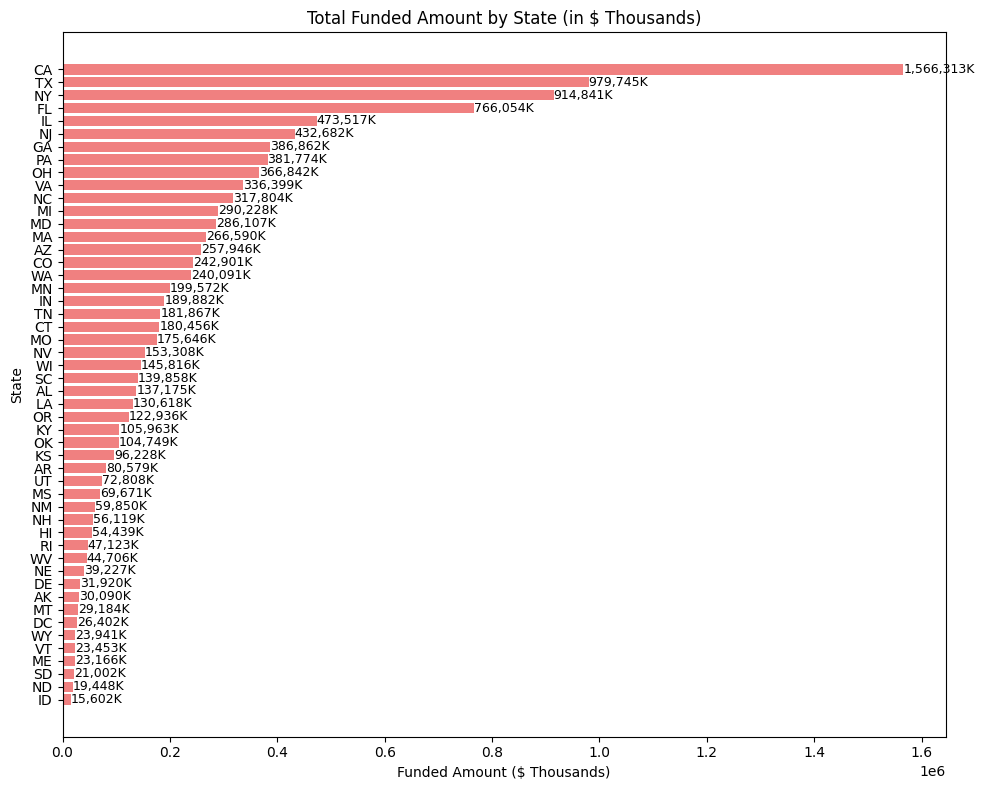

In [16]:
state_funding = df.groupby('addr_state')['loan_amnt'].sum().sort_values(ascending=True)
state_funding_thousands = state_funding/1000

plt.figure(figsize=(10,8))
bars = plt.barh(state_funding_thousands.index, state_funding_thousands.values, color='lightcoral')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height()/2,
             f'{width:,.0f}K', va='center', fontsize=9)

plt.title('Total Funded Amount by State (in $ Thousands)')
plt.xlabel('Funded Amount ($ Thousands)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

Regional Analysis by State for Total Received Amount

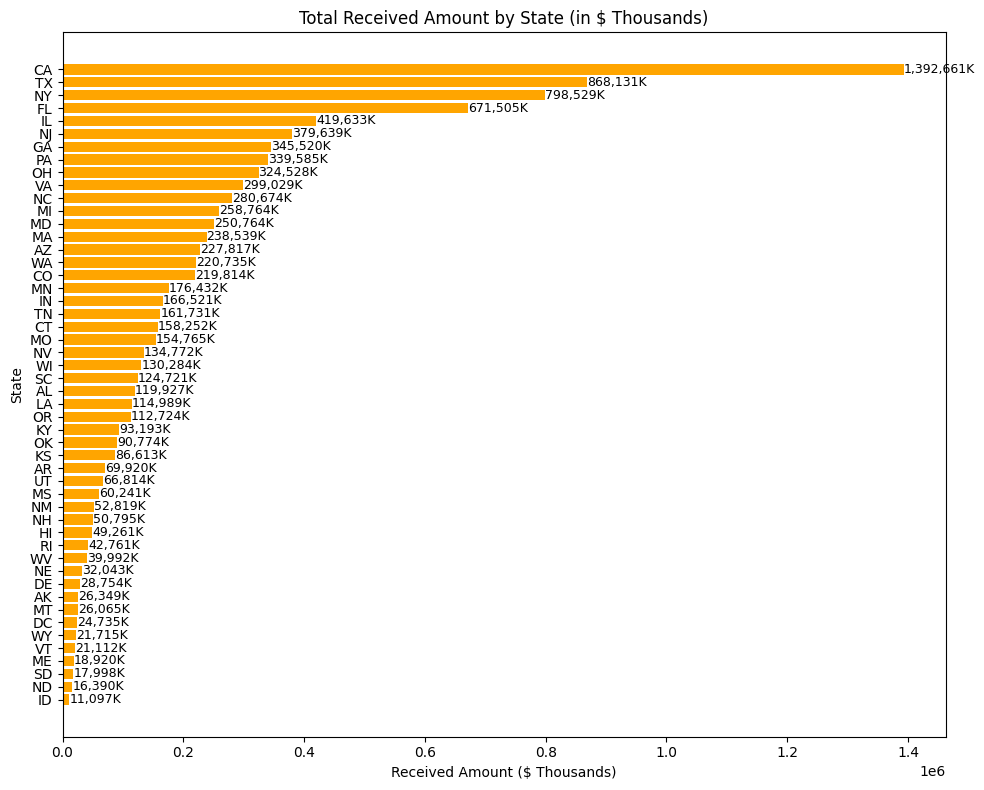

In [17]:
state_received = df.groupby('addr_state')['total_pymnt'].sum().sort_values(ascending=True)
state_received_thousands = state_received/1000

plt.figure(figsize=(10,8))
bars = plt.barh(state_received_thousands.index, state_received_thousands.values, color='orange')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height()/2,
             f'{width:,.0f}K', va='center', fontsize=9)

plt.title('Total Received Amount by State (in $ Thousands)')
plt.xlabel('Received Amount ($ Thousands)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

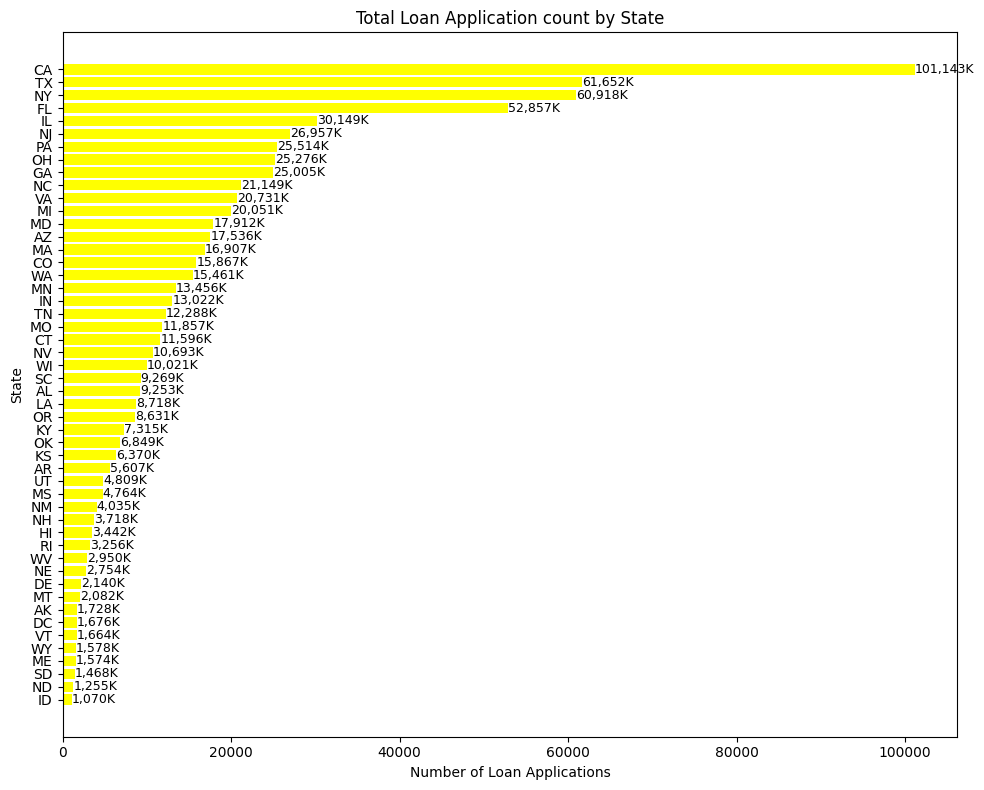

In [18]:
state_loan_applications = df.groupby('addr_state')['id'].count().sort_values(ascending=True)

plt.figure(figsize=(10,8))
bars = plt.barh(state_loan_applications.index, state_loan_applications.values, color='yellow')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height()/2,
             f'{width:,.0f}K', va='center', fontsize=9)

plt.title('Total Loan Application count by State')
plt.xlabel('Number of Loan Applications')
plt.ylabel('State')
plt.tight_layout()
plt.show()

Loan Term Analysis for Total Funded Amount

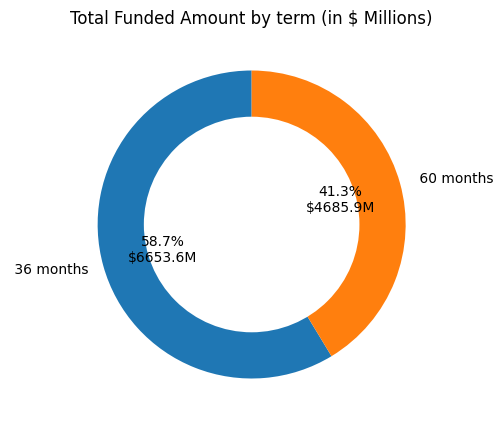

In [19]:
term_funded_millions = df.groupby('term')['loan_amnt'].sum()/1000000

plt.figure(figsize=(5,5))
plt.pie(
    term_funded_millions,
    labels=term_funded_millions.index,
    autopct=lambda p:f"{p:.1f}%\n${p * sum(term_funded_millions)/100:.1f}M",
    startangle=90,
    wedgeprops={'width':0.4}
)
plt.gca().add_artist(plt.Circle((0,0),0.70, fc='white'))
plt.title("Total Funded Amount by term (in $ Millions)")
plt.show()

Loan Term Analysis for Total Received Amount

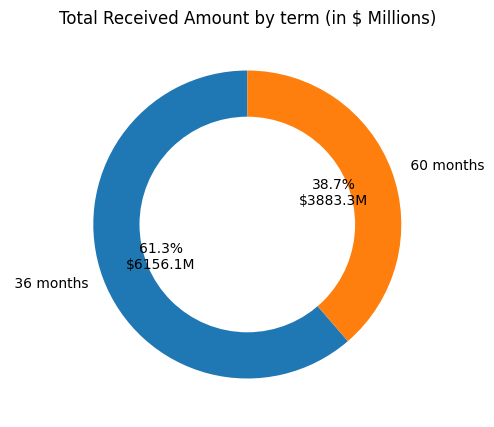

In [20]:
term_received_millions = df.groupby('term')['total_pymnt'].sum()/1000000

plt.figure(figsize=(5,5))
plt.pie(
    term_received_millions,
    labels=term_received_millions.index,
    autopct=lambda p:f"{p:.1f}%\n${p * sum(term_received_millions)/100:.1f}M",
    startangle=90,
    wedgeprops={'width':0.4}
)
plt.gca().add_artist(plt.Circle((0,0),0.70, fc='white'))
plt.title("Total Received Amount by term (in $ Millions)")
plt.show()

Loan Term Analysis for Total Loan Applications

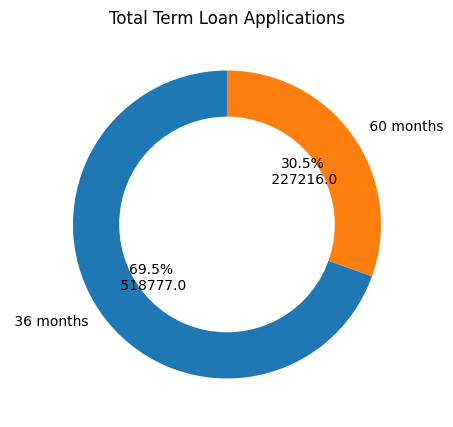

In [21]:
term_loan_Applications = df.groupby('term')['id'].count()

plt.figure(figsize=(5,5))
plt.pie(
    term_loan_Applications,
    labels=term_loan_Applications.index,
    autopct=lambda p:f"{p:.1f}%\n {p * sum(term_loan_Applications)/100:.1f}",
    startangle=90,
    wedgeprops={'width':0.4}
)
plt.gca().add_artist(plt.Circle((0,0),0.70, fc='white'))
plt.title("Total Term Loan Applications")
plt.show()

Employee Length Analysis for Total Funded Amount

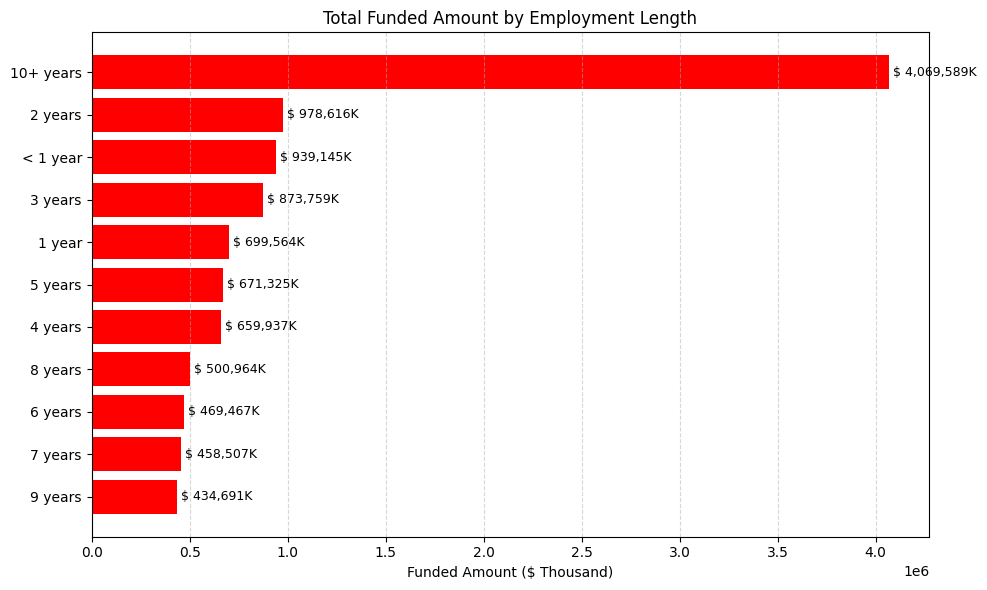

In [22]:
emp_funded = df.groupby('emp_length')['loan_amnt'].sum().sort_values()/1000

plt.figure(figsize=(10,6))
bars = plt.barh(emp_funded.index, emp_funded,color='red')

for bar in bars:
    width=bar.get_width()
    plt.text(width+5, bar.get_y()+ bar.get_height()/2, f" $ {width:,.0f}K", va='center',fontsize=9)

plt.xlabel("Funded Amount ($ Thousand)")
plt.title("Total Funded Amount by Employment Length")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Employee Length Analysis for Total Received Amount

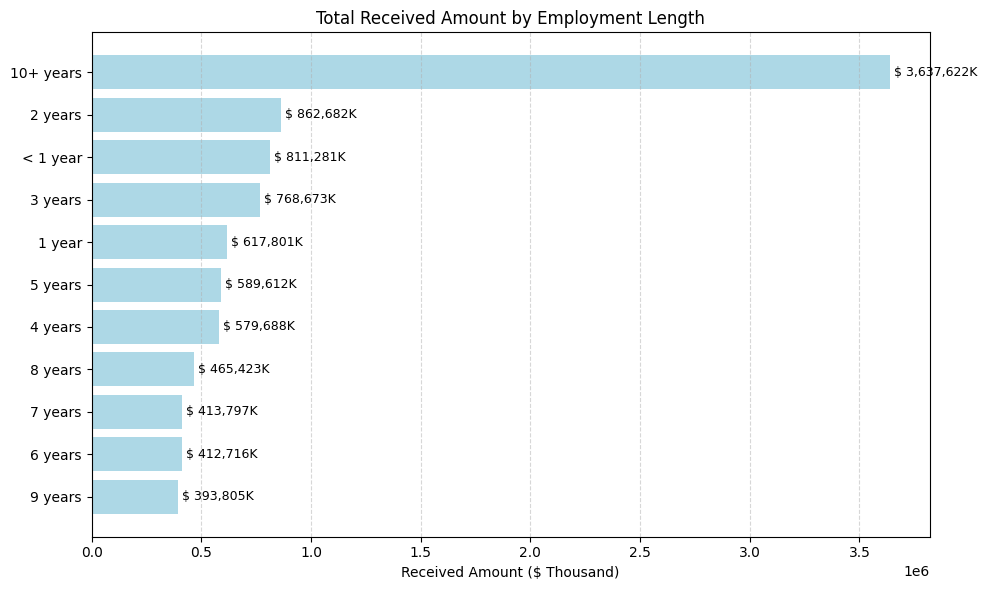

In [23]:
emp_received = df.groupby('emp_length')['total_pymnt'].sum().sort_values()/1000

plt.figure(figsize=(10,6))
bars = plt.barh(emp_received.index, emp_received,color='lightblue')

for bar in bars:
    width=bar.get_width()
    plt.text(width+5, bar.get_y()+ bar.get_height()/2, f" $ {width:,.0f}K", va='center',fontsize=9)

plt.xlabel("Received Amount ($ Thousand)")
plt.title("Total Received Amount by Employment Length")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Employee Length Analysis for Total Loan Applications

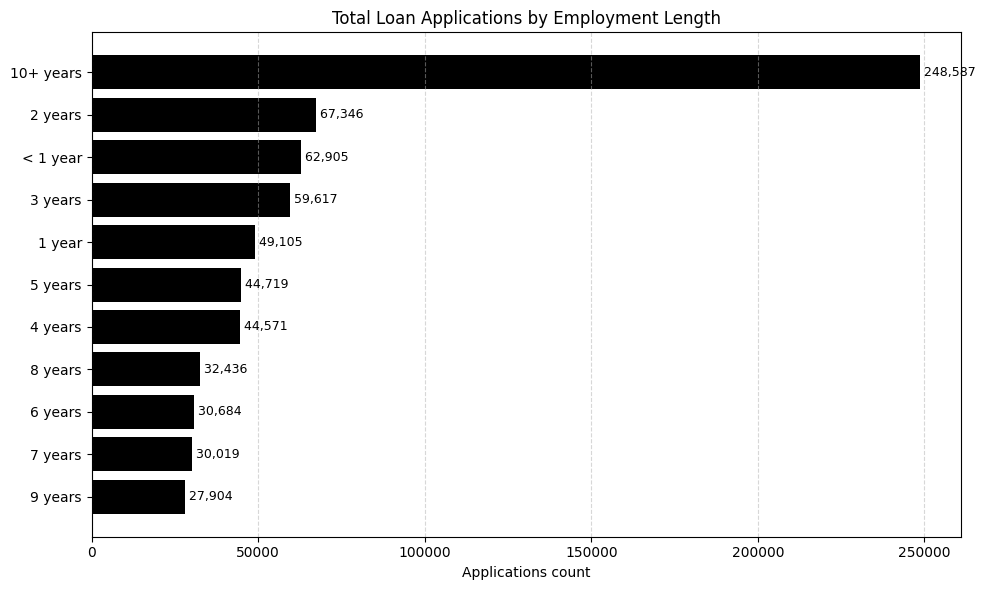

In [24]:
emp_loan_applications = df.groupby('emp_length')['id'].count().sort_values()

plt.figure(figsize=(10,6))
bars = plt.barh(emp_loan_applications.index, emp_loan_applications,color='black')

for bar in bars:
    width=bar.get_width()
    plt.text(width+5, bar.get_y()+ bar.get_height()/2, f" {width:,.0f}", va='center',fontsize=9)

plt.xlabel("Applications count")
plt.title("Total Loan Applications by Employment Length")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Loan Purpose Breakdown for Total Funded Amount

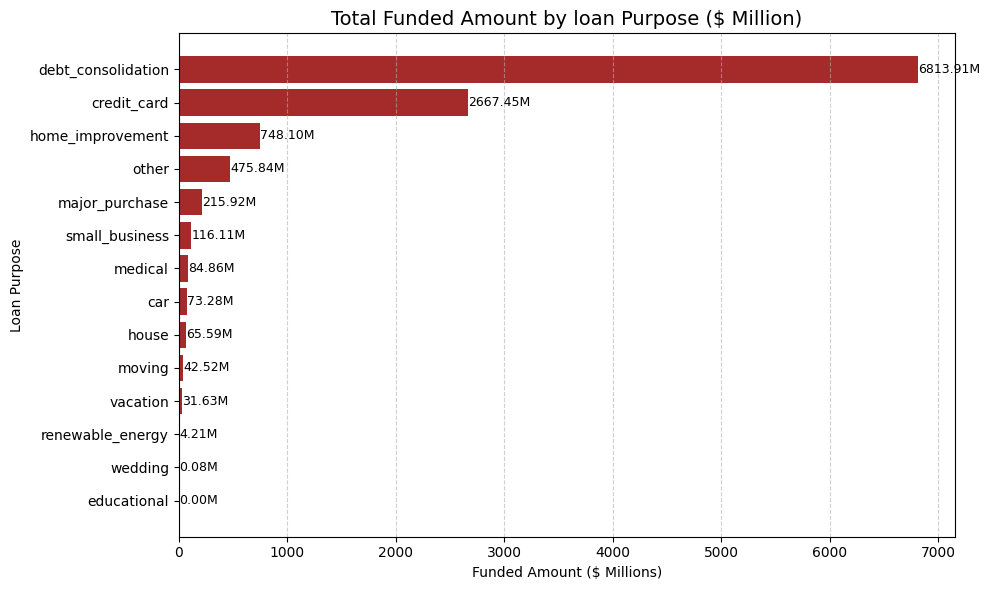

In [25]:
purpose_funding_million = (df.groupby('purpose')['loan_amnt'].sum().sort_values()/1000000)

plt.figure(figsize=(10,6))
bars = plt.barh(purpose_funding_million.index, purpose_funding_million.values, color='brown')

for bar in bars:
    width = bar.get_width()
    plt.text(width+0.1, bar.get_y()+bar.get_height()/2, f"{width:.2f}M", va ='center', fontsize=9)

plt.title("Total Funded Amount by loan Purpose ($ Million)", fontsize=14)
plt.xlabel("Funded Amount ($ Millions)")
plt.ylabel("Loan Purpose")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Loan Purpose Breakdown for Total Received Amount

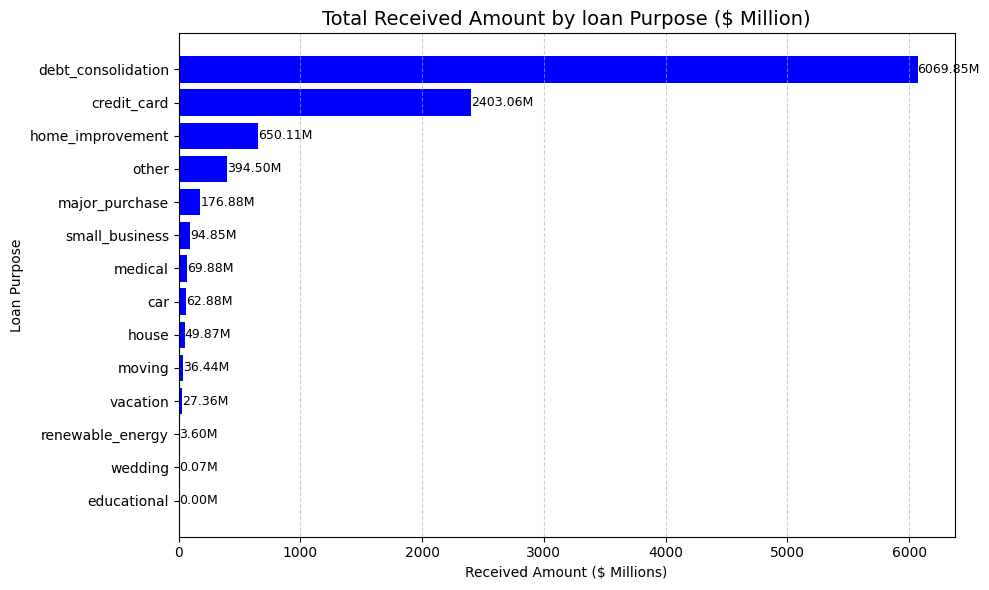

In [26]:
purpose_received_million = (df.groupby('purpose')['total_pymnt'].sum().sort_values()/1000000)

plt.figure(figsize=(10,6))
bars = plt.barh(purpose_received_million.index, purpose_received_million.values, color='blue')

for bar in bars:
    width = bar.get_width()
    plt.text(width+0.1, bar.get_y()+bar.get_height()/2, f"{width:.2f}M", va ='center', fontsize=9)

plt.title("Total Received Amount by loan Purpose ($ Million)", fontsize=14)
plt.xlabel("Received Amount ($ Millions)")
plt.ylabel("Loan Purpose")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Loan Purpose Breakdown for Total Loan Applications

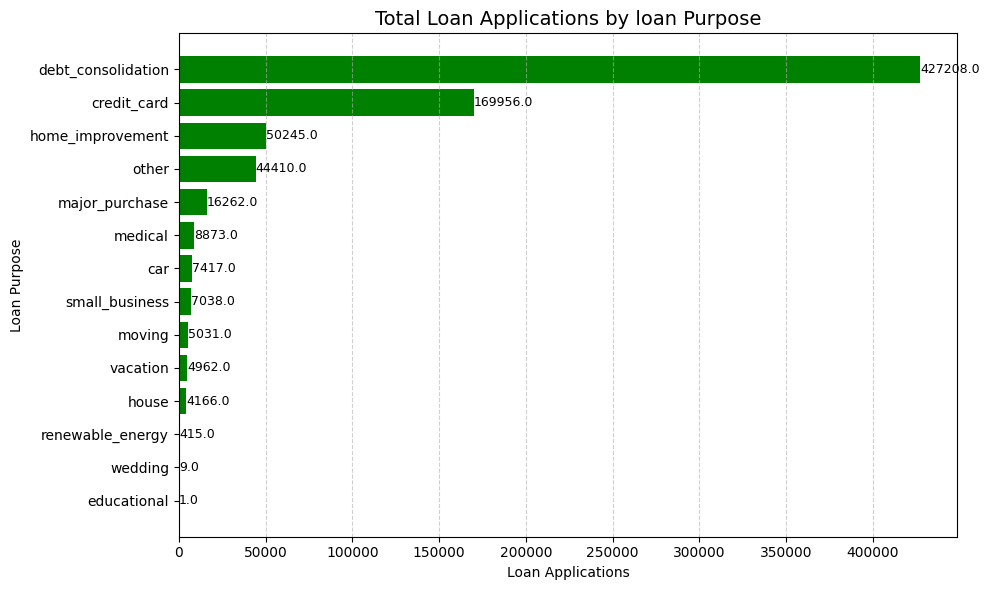

In [27]:
purpose_loan_applications = (df.groupby('purpose')['id'].count().sort_values())

plt.figure(figsize=(10,6))
bars = plt.barh(purpose_loan_applications.index, purpose_loan_applications.values, color='green')

for bar in bars:
    width = bar.get_width()
    plt.text(width+0.1, bar.get_y()+bar.get_height()/2, f"{width:.1f}", va ='center', fontsize=9)

plt.title("Total Loan Applications by loan Purpose", fontsize=14)
plt.xlabel("Loan Applications")
plt.ylabel("Loan Purpose")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()